In [27]:
#!/usr/bin/env python3
"""
Mesh Visualization

Author: Moon Ying (yying7@jh.edu)
Python Version: 3.9.7

This script generates a 3D triangular mesh, for visualization of the FEM used in continuum membrane model 
The mesh structure is built using PyVista.

Key Features:
- Generates a structured triangular mesh and visualization.
"""

import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from mpl_toolkits.mplot3d import Axes3D


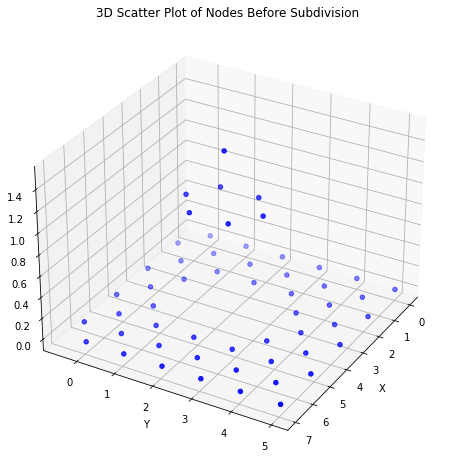

In [28]:
# Define the array to hold the points (now with 3 coordinates: x, y, z)
X = np.zeros((9, 6, 3))

# Generate points for equilateral triangles with a slight bump in the middle
for i in range(0, 9):
    for j in range(0, 6):
        X[i][j][0] = i * np.sqrt(3) / 2.0
        X[i][j][1] = j * 1.0 - (i % 2) * 0.5
        # Create a bump in the middle
        if (i,j) == (4,2):
            X[i][j][2] = 1.5
        elif 3 <= i <= 5 and 2 <= j <= 3 or (i,j) == (4,1):
            X[i][j][2] = 1.0
        else:
            X[i][j][2] = 0.0

# Plot the 3D scatter plot of the points before subdivision
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, :, 0], X[:, :, 1], X[:, :, 2], color='blue')

ax.set_title("3D Scatter Plot of Nodes Before Subdivision")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.view_init(elev=30, azim=30)
plt.show()

In [29]:

# Flatten the array for pyvista mesh creation
points = X.reshape(-1, 3)

# Create pyvista PolyData object
mesh = pv.PolyData(points)

# Define the connectivity of the mesh (triangles)
faces = []
for i in range(8):
    for j in range(5):
        p1 = i * 6 + j
        p2 = (i + 1) * 6 + j
        p3 = p1 + 1
        p4 = p2 + 1
        if i % 2 == 0 :
            faces.append([3, p1, p2, p4])  # Triangle 1
            faces.append([3, p4, p3, p1])  # Triangle 2
        else:
            faces.append([3, p3, p1, p2])  # Triangle 1
            faces.append([3, p2, p4, p3])  # Triangle 2

# Convert list to numpy array with shape (n_faces, 4)
faces = np.array(faces).flatten()
print(faces)

[ 3  0  6  7  3  7  1  0  3  1  7  8  3  8  2  1  3  2  8  9  3  9  3  2
  3  3  9 10  3 10  4  3  3  4 10 11  3 11  5  4  3  7  6 12  3 12 13  7
  3  8  7 13  3 13 14  8  3  9  8 14  3 14 15  9  3 10  9 15  3 15 16 10
  3 11 10 16  3 16 17 11  3 12 18 19  3 19 13 12  3 13 19 20  3 20 14 13
  3 14 20 21  3 21 15 14  3 15 21 22  3 22 16 15  3 16 22 23  3 23 17 16
  3 19 18 24  3 24 25 19  3 20 19 25  3 25 26 20  3 21 20 26  3 26 27 21
  3 22 21 27  3 27 28 22  3 23 22 28  3 28 29 23  3 24 30 31  3 31 25 24
  3 25 31 32  3 32 26 25  3 26 32 33  3 33 27 26  3 27 33 34  3 34 28 27
  3 28 34 35  3 35 29 28  3 31 30 36  3 36 37 31  3 32 31 37  3 37 38 32
  3 33 32 38  3 38 39 33  3 34 33 39  3 39 40 34  3 35 34 40  3 40 41 35
  3 36 42 43  3 43 37 36  3 37 43 44  3 44 38 37  3 38 44 45  3 45 39 38
  3 39 45 46  3 46 40 39  3 40 46 47  3 47 41 40  3 43 42 48  3 48 49 43
  3 44 43 49  3 49 50 44  3 45 44 50  3 50 51 45  3 46 45 51  3 51 52 46
  3 47 46 52  3 52 53 47]


/opt/anaconda3/lib/python3.9/site-packages/pyvista/jupyter/notebook.py:58: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


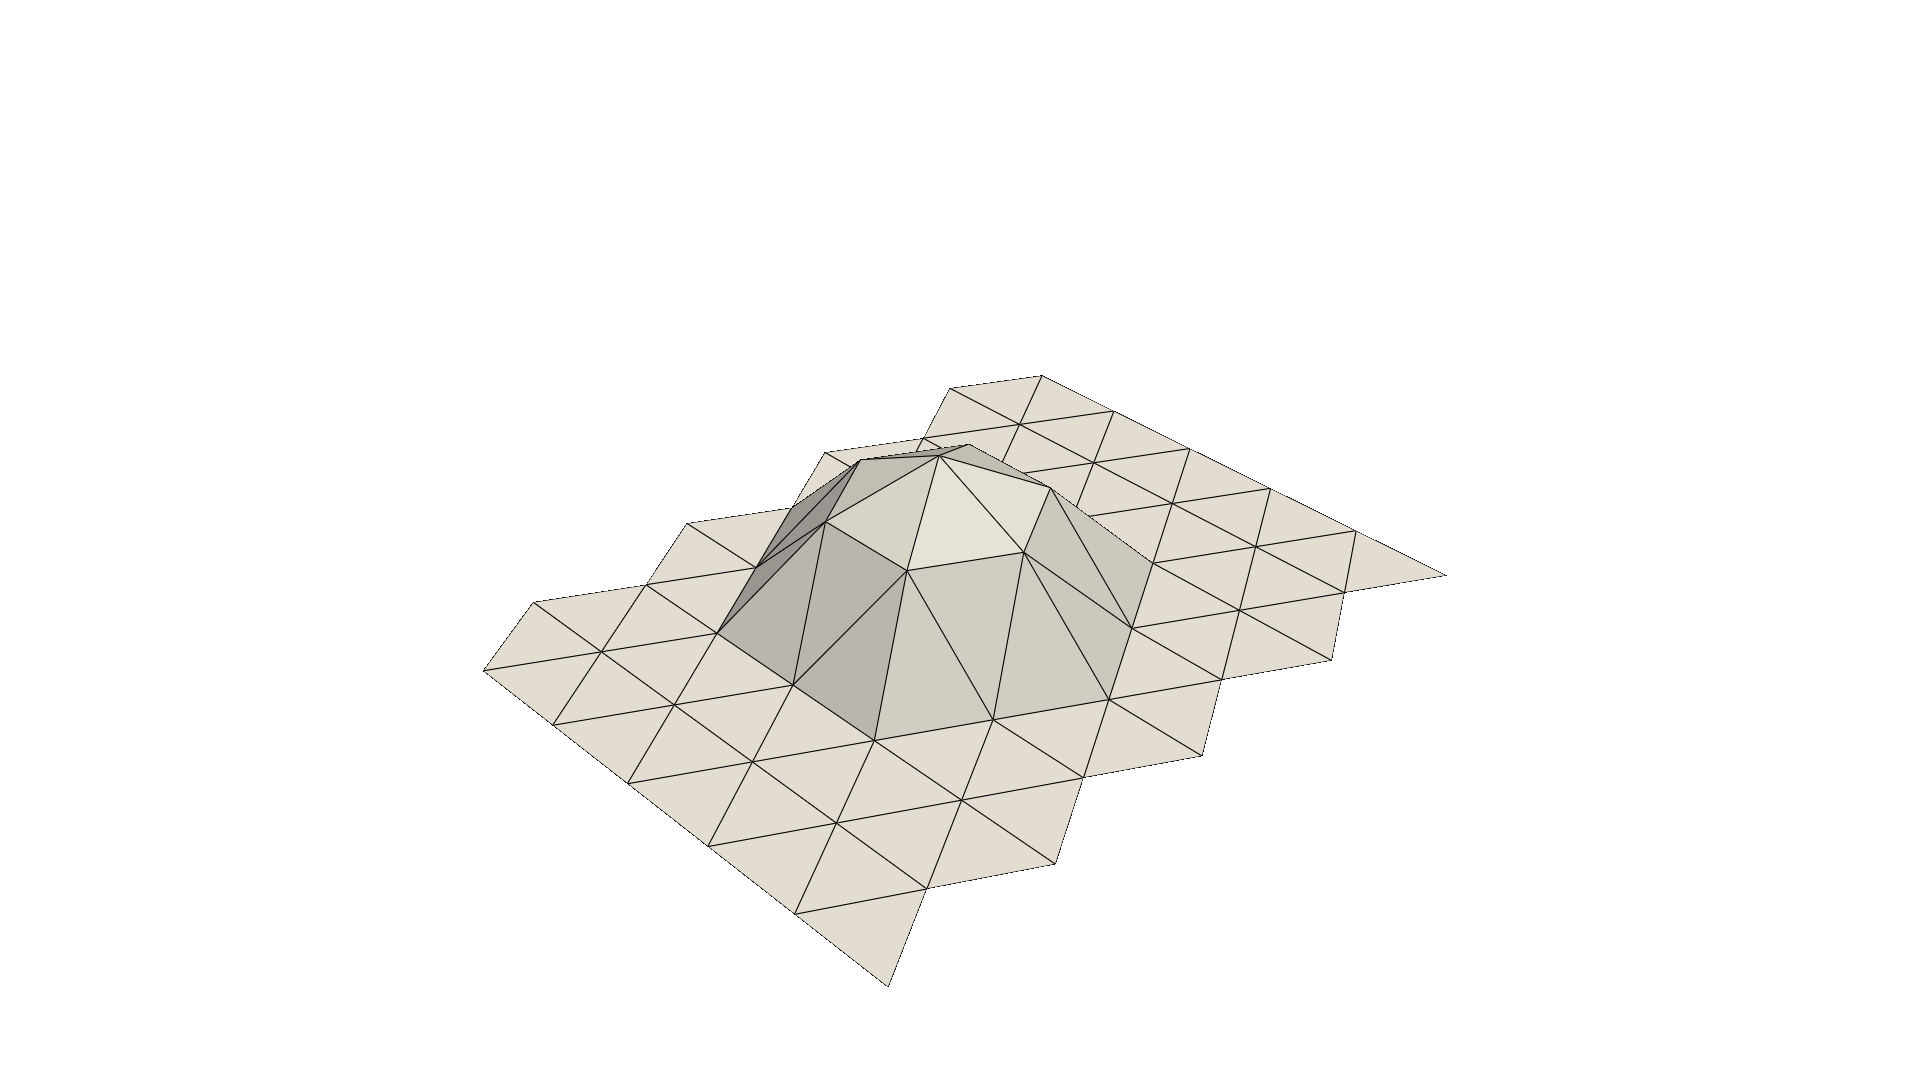

In [30]:
# Create the mesh
tri_mesh = pv.PolyData(mesh.points, faces)


# Plot the subdivided mesh with edge connectivity
plotter = pv.Plotter()
plotter.add_mesh(tri_mesh, show_edges=True, color='white')
plotter.background_color = 'white'  # Set the background to white
plotter.view_isometric()

# Set a high window size for high resolution
plotter.window_size = [1920, 1080]  # Increase the size for higher resolution

# Render the plot and save as a high-resolution PNG
plotter.screenshot('graph_subdiv_0.png')

plotter.show()


/opt/anaconda3/lib/python3.9/site-packages/pyvista/jupyter/notebook.py:58: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


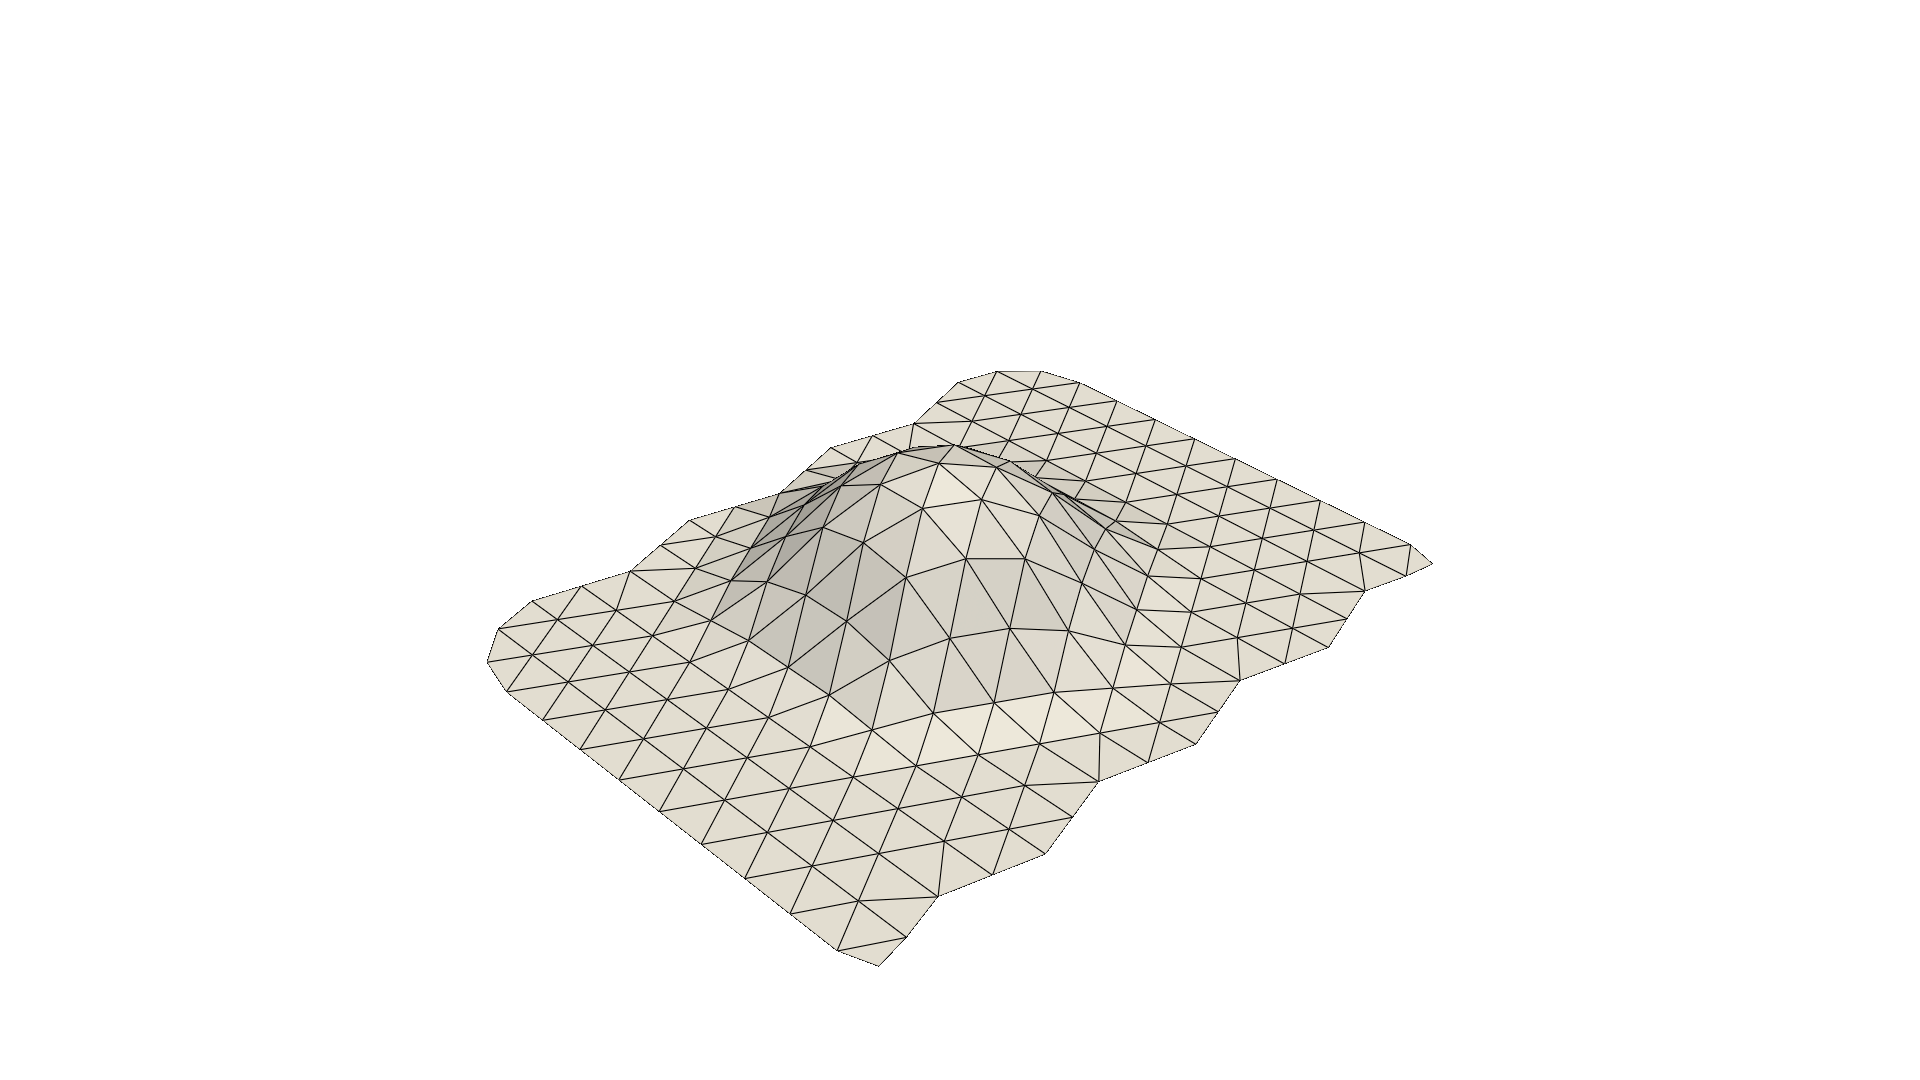

In [31]:
# Create the mesh
tri_mesh = pv.PolyData(mesh.points, faces)

# Apply Loop's subdivision
X_subdiv = tri_mesh.subdivide(1, subfilter='loop')

# Plot the subdivided mesh with edge connectivity
plotter = pv.Plotter()
plotter.add_mesh(X_subdiv, show_edges=True, color='white')
plotter.background_color = 'white'  # Set the background to white
plotter.view_isometric()

# Set a high window size for high resolution
plotter.window_size = [1920, 1080]  # Increase the size for higher resolution

# Render the plot and save as a high-resolution PNG
plotter.screenshot('graph_subdiv_1.png')

plotter.show()

/opt/anaconda3/lib/python3.9/site-packages/pyvista/jupyter/notebook.py:58: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


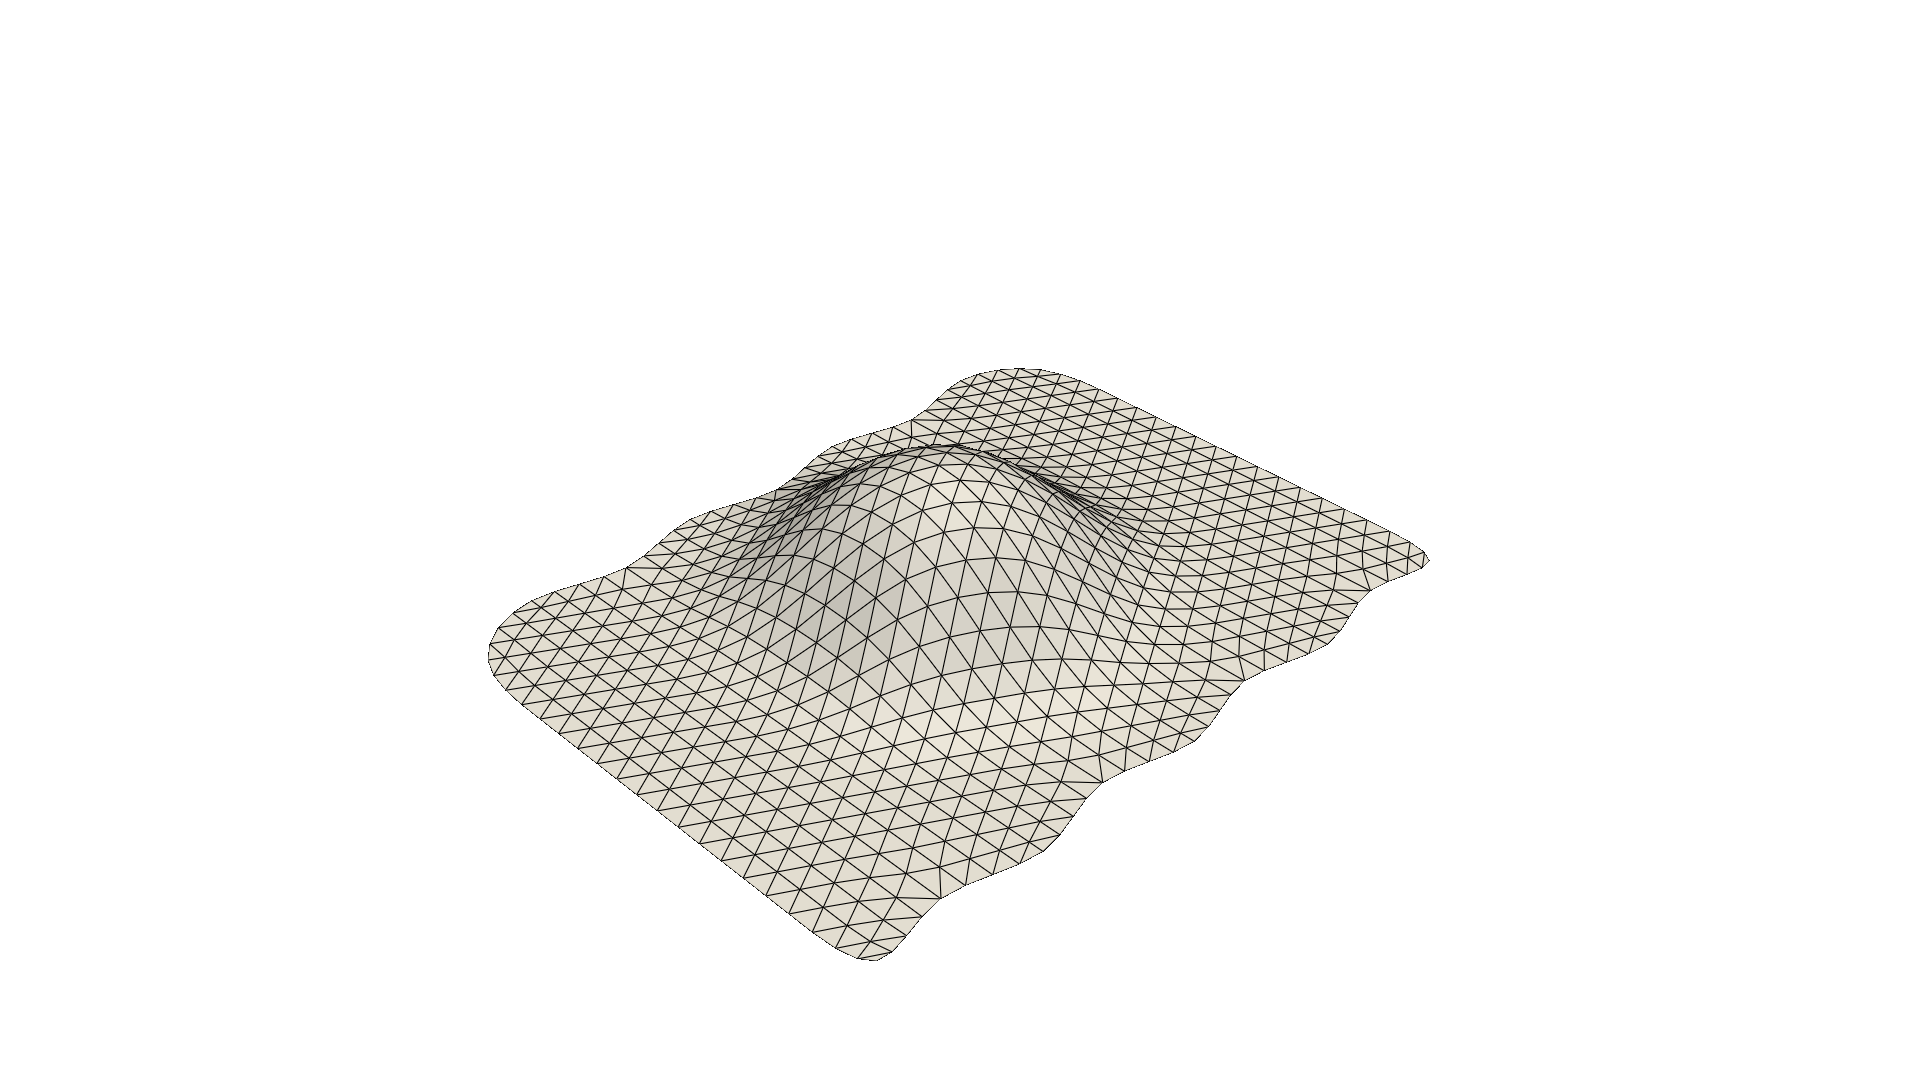

In [32]:
# Create the mesh
tri_mesh = pv.PolyData(mesh.points, faces)

# Apply Loop's subdivision
X_subdiv = tri_mesh.subdivide(2, subfilter='loop')

# Plot the subdivided mesh with edge connectivity
plotter = pv.Plotter()
plotter.add_mesh(X_subdiv, show_edges=True, color='white')
plotter.background_color = 'white'  # Set the background to white
plotter.view_isometric()

# Set a high window size for high resolution
plotter.window_size = [1920, 1080]  # Increase the size for higher resolution

# Render the plot and save as a high-resolution PNG
plotter.screenshot('graph_subdiv_2.png')

plotter.show()

/opt/anaconda3/lib/python3.9/site-packages/pyvista/jupyter/notebook.py:58: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


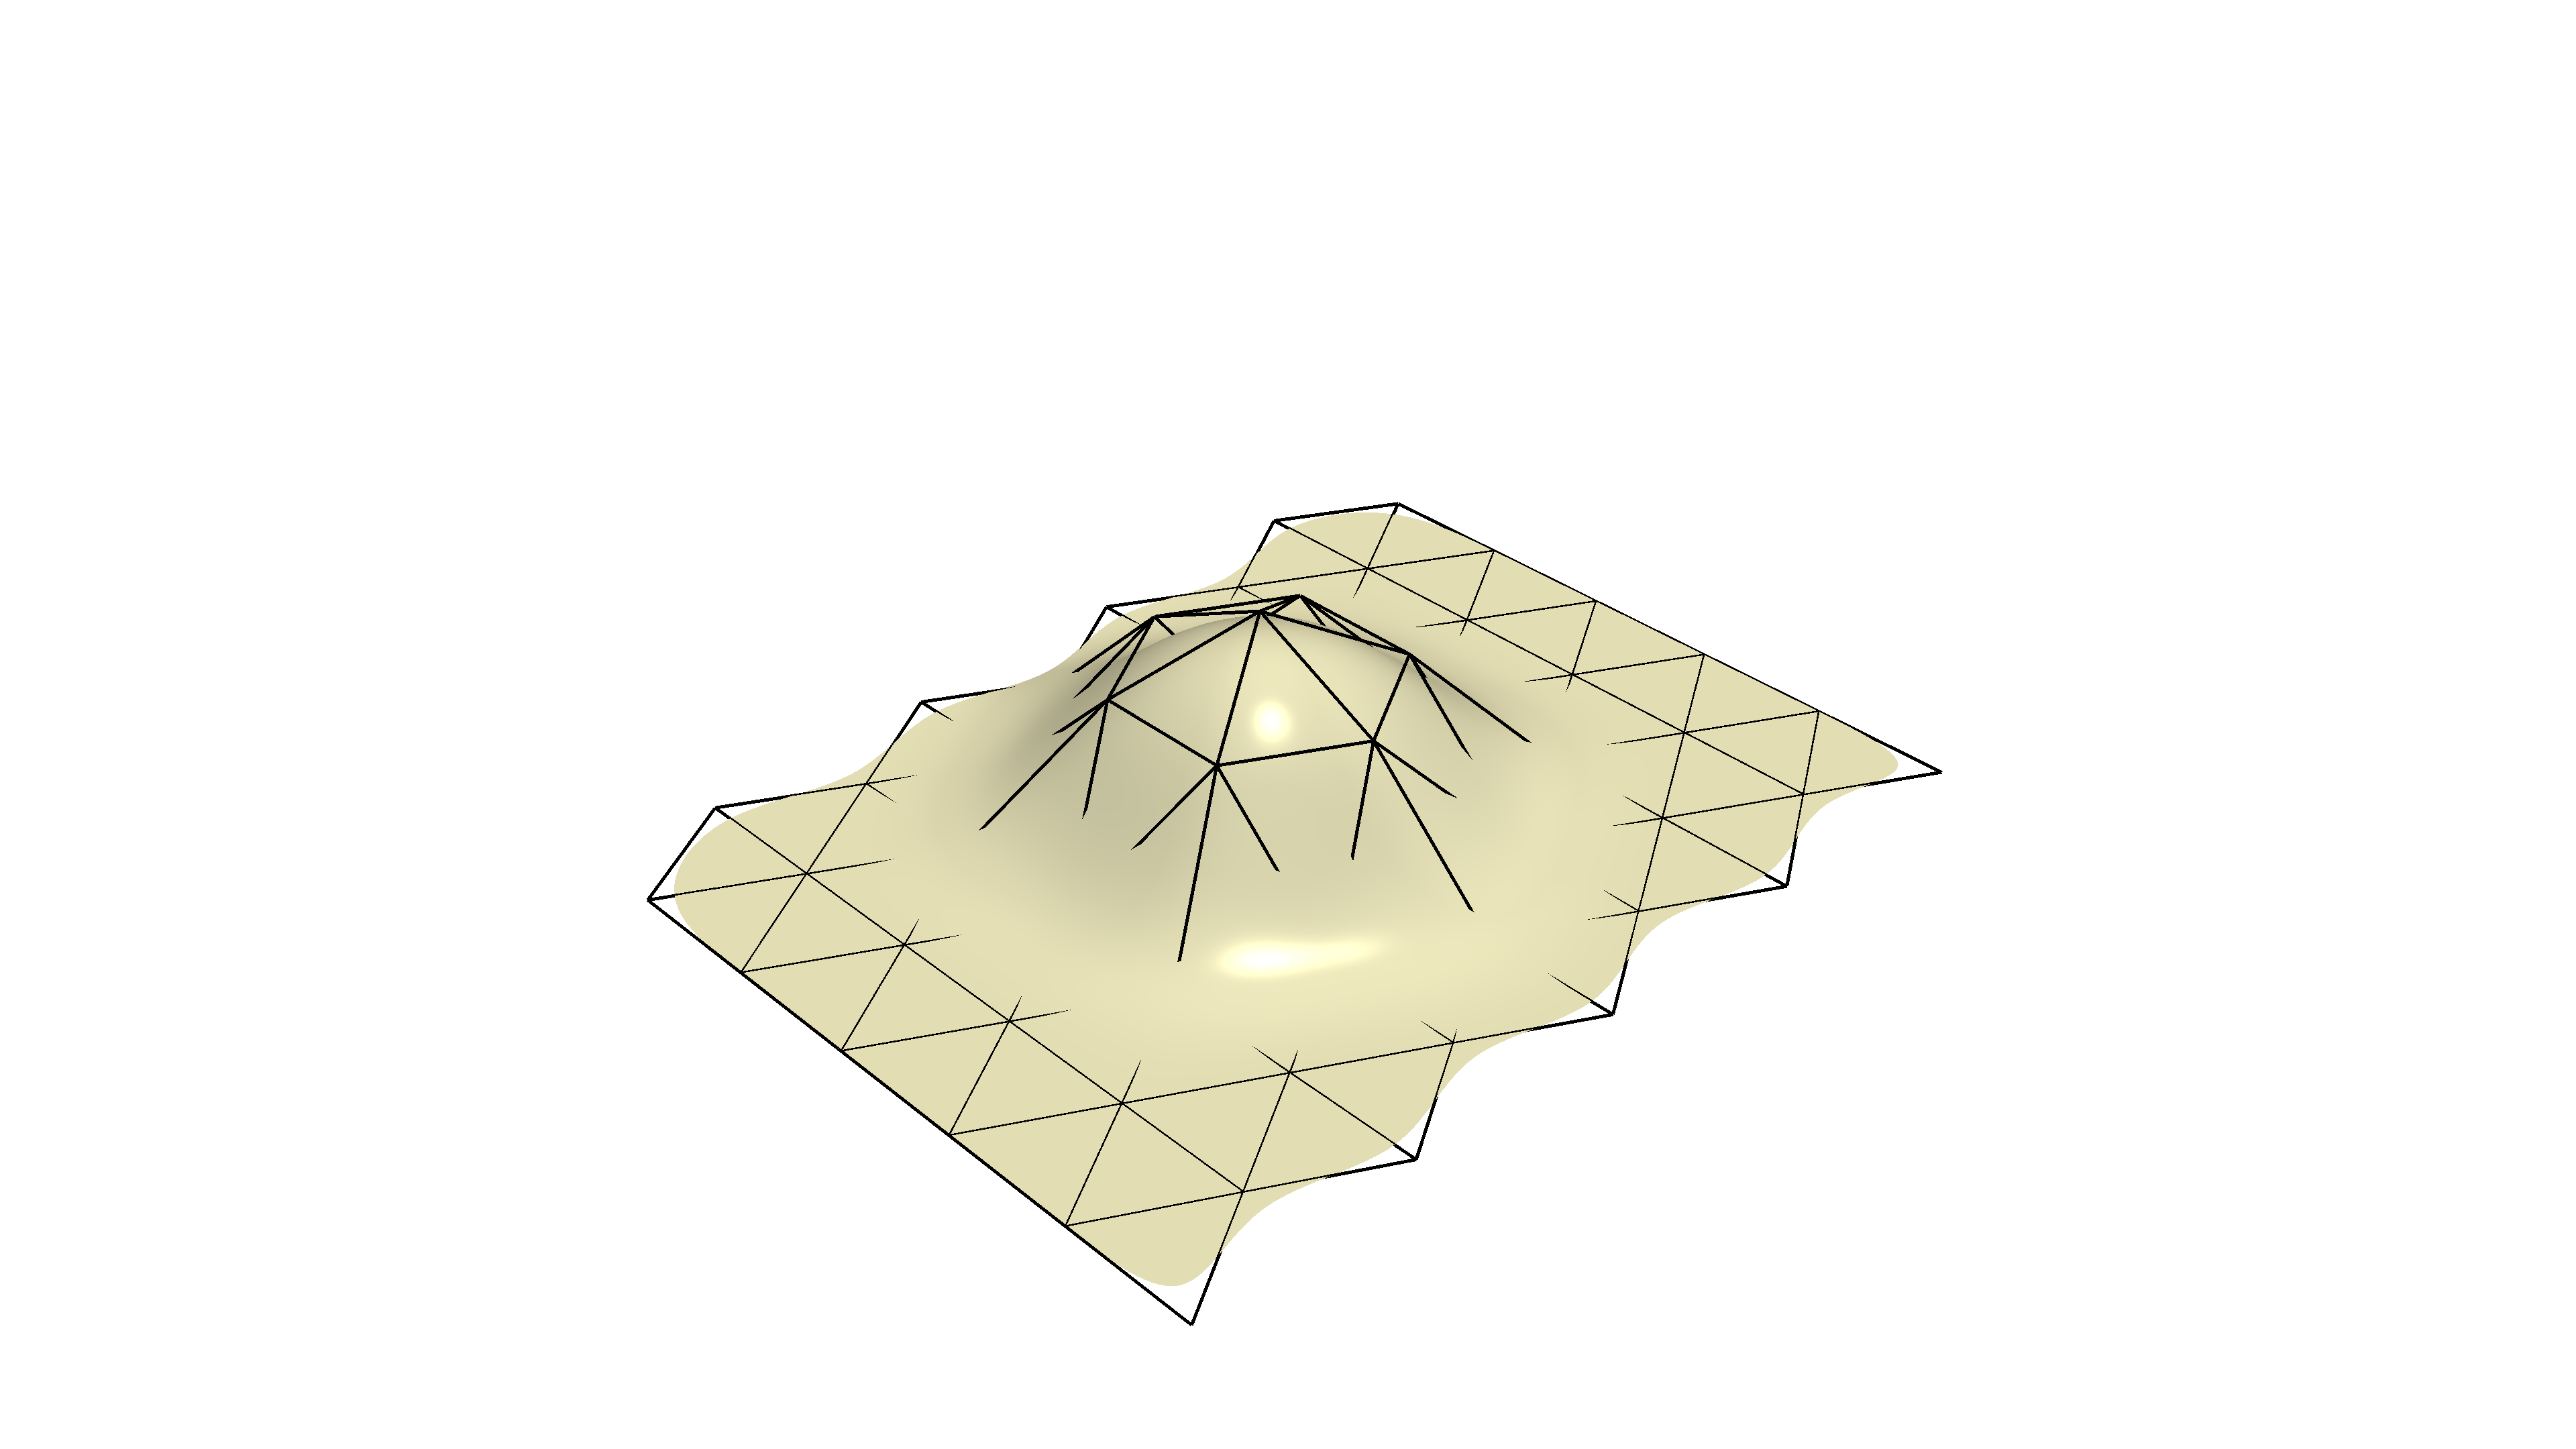

In [33]:
# Create the mesh
tri_mesh = pv.PolyData(mesh.points, faces)

# Apply Loop's subdivision
X_subdiv = tri_mesh.subdivide(5, subfilter='loop')

# Plot the original mesh edge connectivity
# Plot the subdivided mesh
plotter = pv.Plotter()
plotter.background_color = 'white'  # Set the background to white
plotter.add_mesh(tri_mesh, color='black', style='wireframe', line_width=5)
plotter.add_mesh(X_subdiv, show_edges=False, color='#FFFFDC',
                 smooth_shading=True, specular=0.5)

# Set a high window size for high resolution
plotter.window_size = [3840, 2160]  # Increase the size for higher resolution

# Render the plot and save as a high-resolution PNG
plotter.screenshot('graph_limit_surface_high_resolution_plot.png')

plotter.show()

/opt/anaconda3/lib/python3.9/site-packages/pyvista/jupyter/notebook.py:58: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


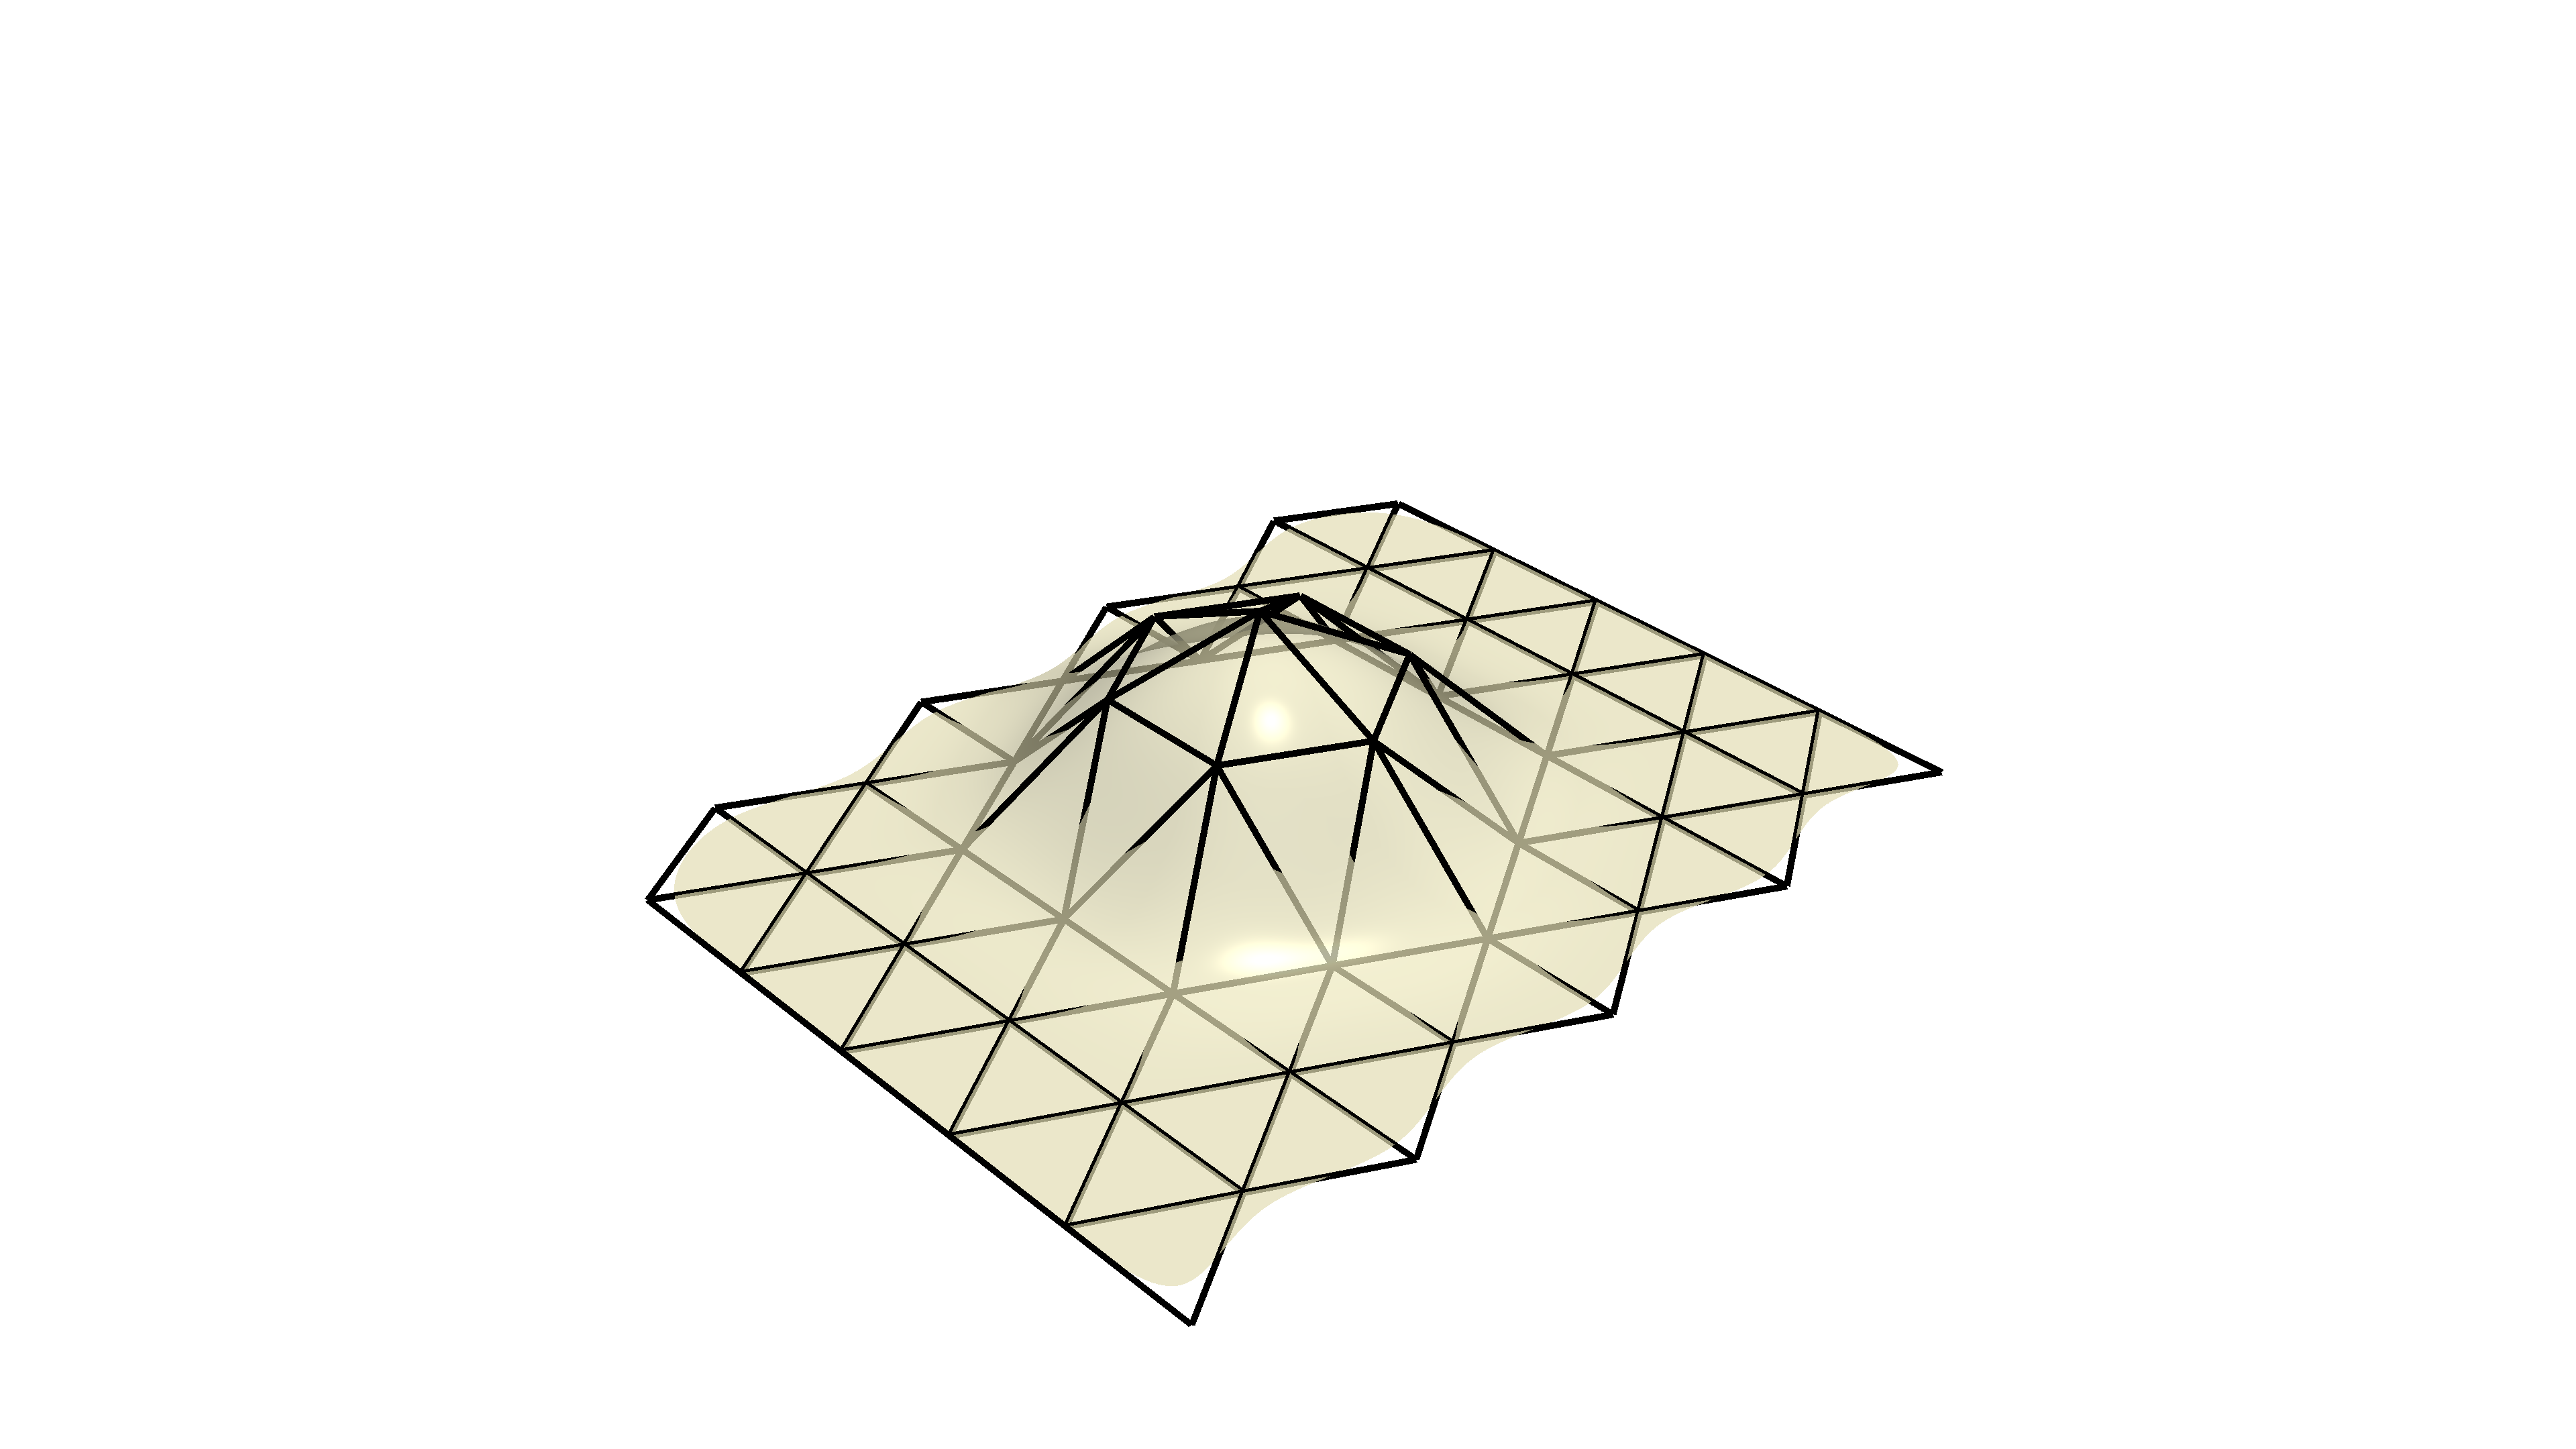

In [34]:
# Create the mesh
tri_mesh = pv.PolyData(mesh.points, faces)

# Apply Loop's subdivision
X_subdiv = tri_mesh.subdivide(5, subfilter='loop')

# Plot the original mesh edge connectivity
# Plot the subdivided mesh
plotter = pv.Plotter()
plotter.background_color = 'white'  # Set the background to white
plotter.add_mesh(tri_mesh, color='black', style='wireframe', line_width=10)
plotter.add_mesh(X_subdiv, show_edges=False, color='#FFFFDC',
                 smooth_shading=True, specular=0.5, opacity=0.7)

# Set the camera position (view angle)
# plotter.camera_position = 'xy'  # Example positions: 'xy', 'xz', 'yz', 'isometric'

# Set a high window size for high resolution
plotter.window_size = [3840, 2160]  # Increase the size for higher resolution

# Render the plot and save as a high-resolution PNG
plotter.screenshot('graph_limit_surface_high_resolution_plot_emphasize_mesh.png')

plotter.show()

/opt/anaconda3/lib/python3.9/site-packages/pyvista/jupyter/notebook.py:58: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


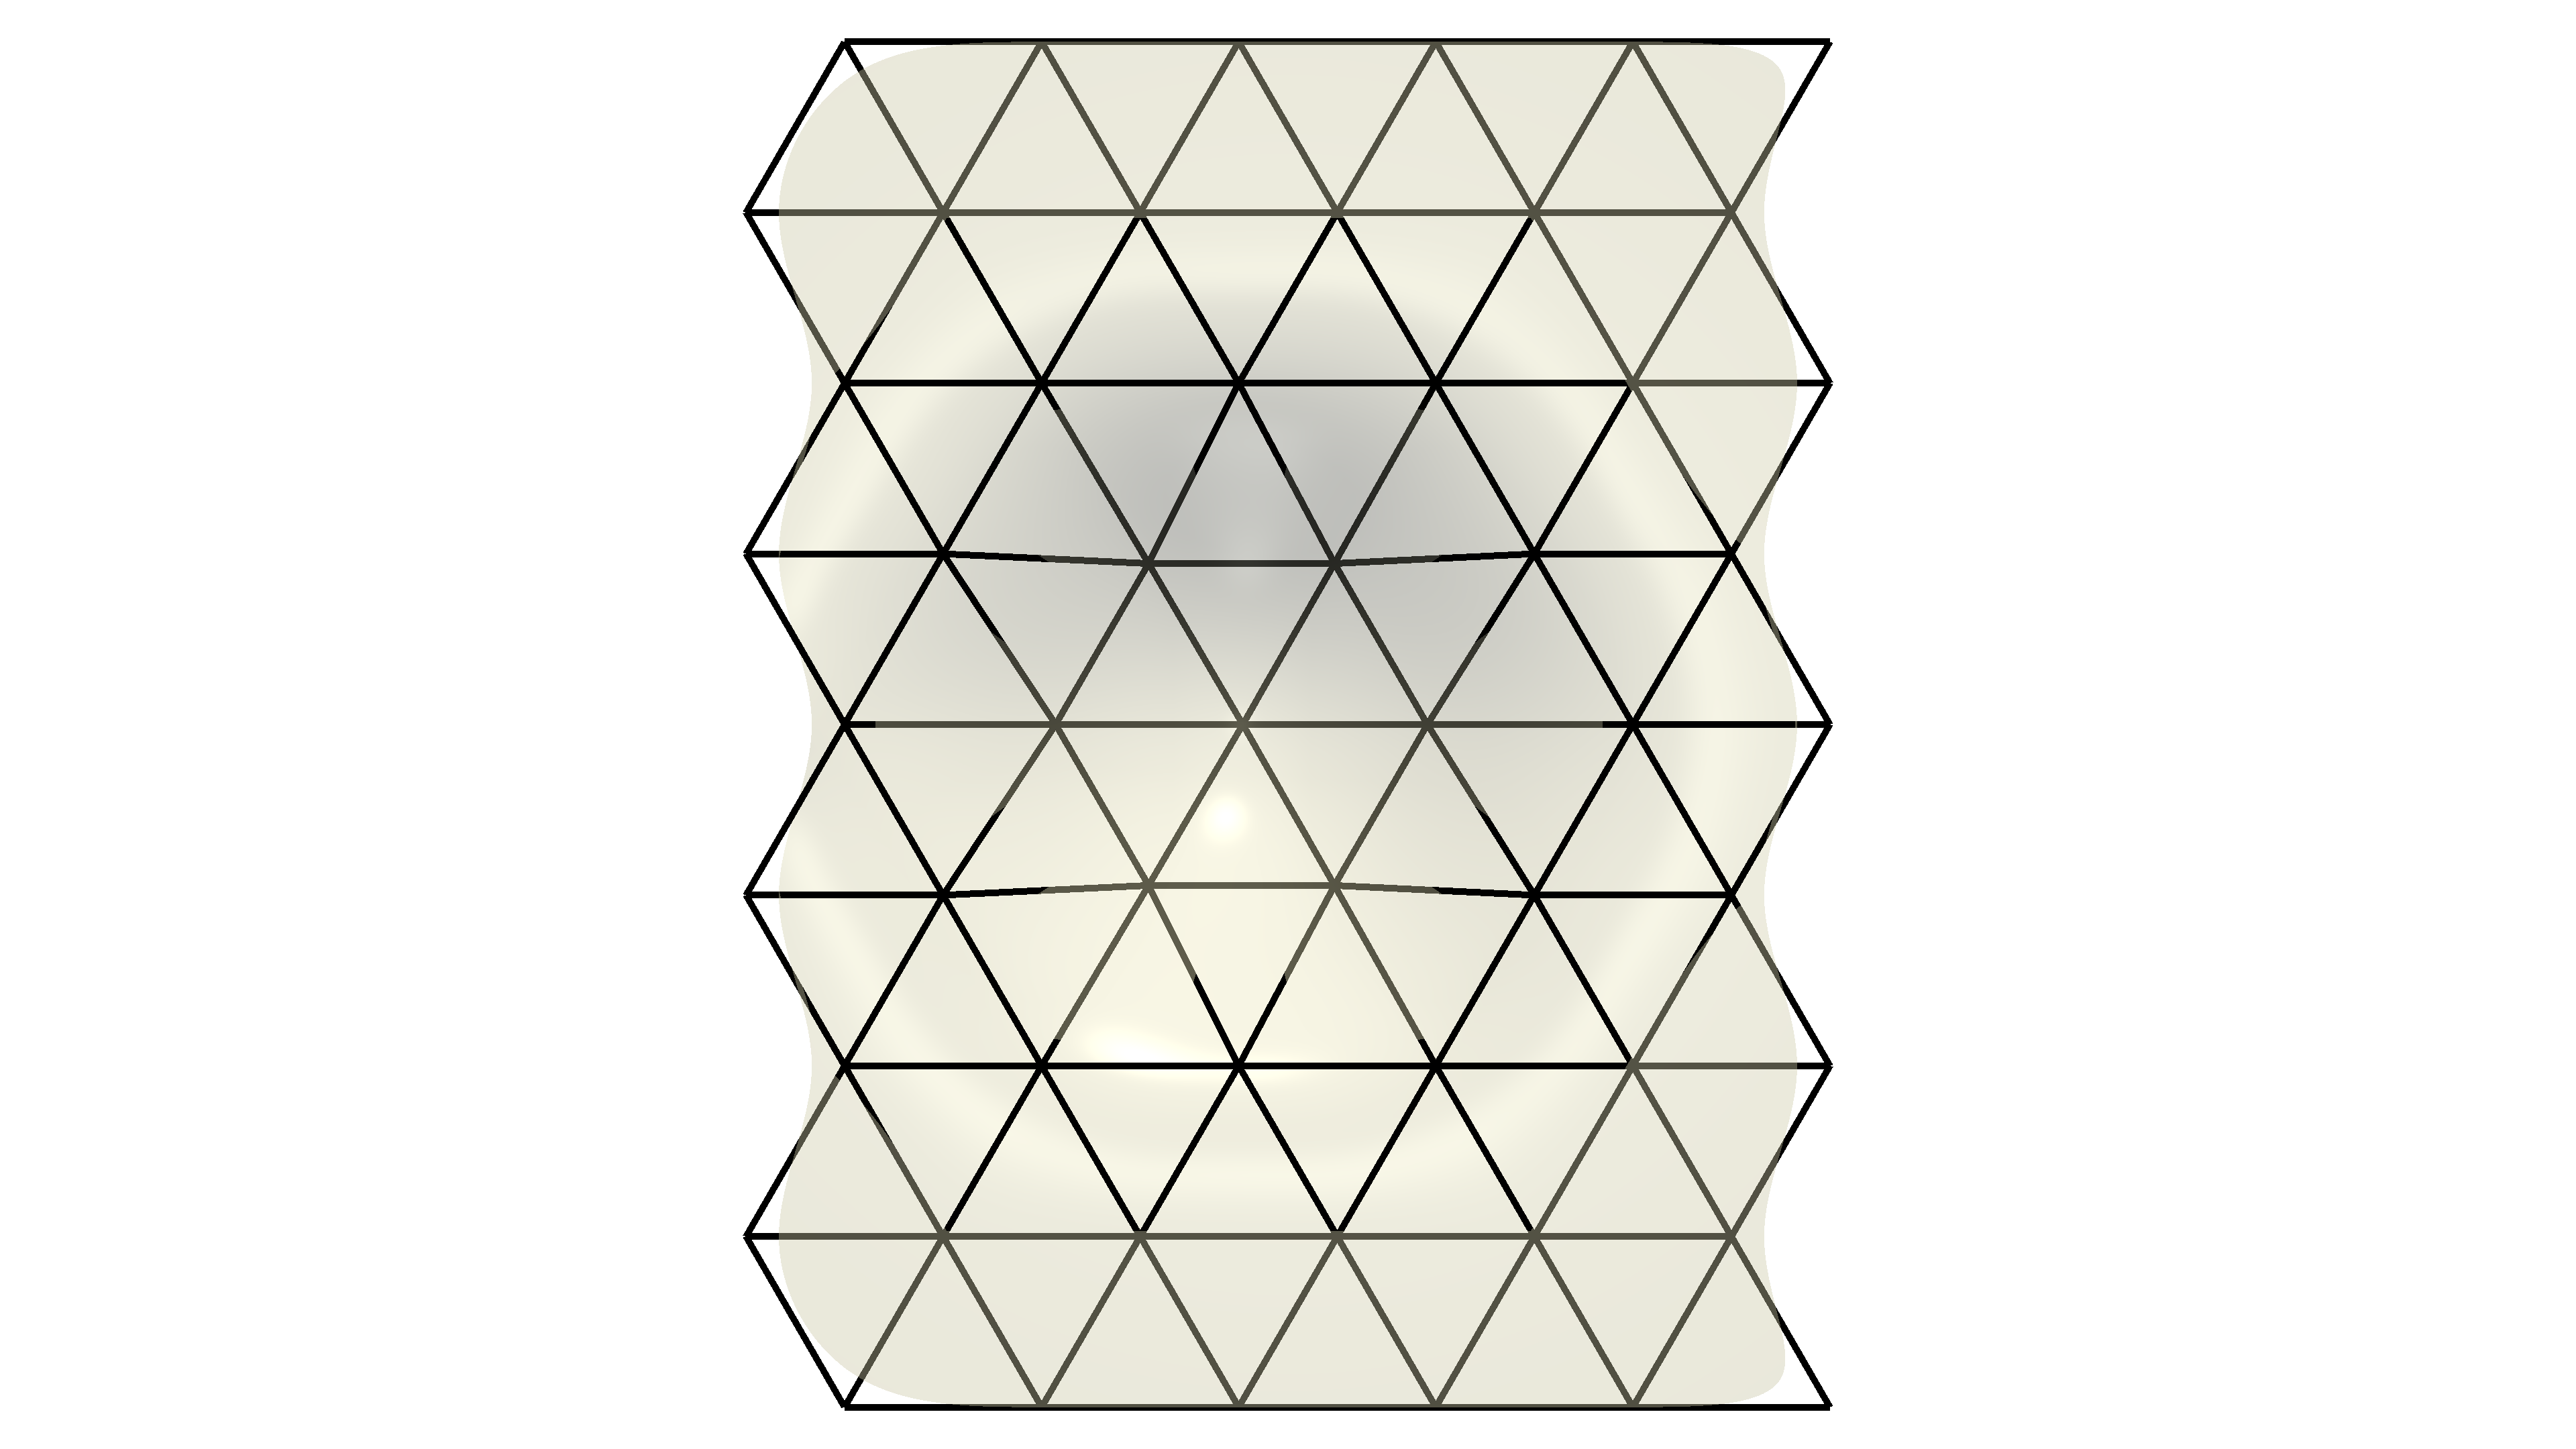

: 

In [40]:
# Create the mesh
tri_mesh = pv.PolyData(mesh.points, faces)

# Apply Loop's subdivision
X_subdiv = tri_mesh.subdivide(5, subfilter='loop')

# Plot the original mesh edge connectivity
# Plot the subdivided mesh
plotter = pv.Plotter()
plotter.background_color = 'white'  # Set the background to white
plotter.add_mesh(tri_mesh, color='black', style='wireframe', line_width=10)
plotter.add_mesh(X_subdiv, show_edges=False, color='#FFFFDC',
                 smooth_shading=True, specular=0.5, opacity=0.4)

# Set the camera position (view angle)
# plotter.camera_position = 'xy'  # Example positions: 'xy', 'xz', 'yz', 'isometric'

# Set a high window size for high resolution
plotter.window_size = [3840, 2160]  # Increase the size for higher resolution



# Set camera position for a top-down view
plotter.camera_position = 'yx'  # Ensures a top-down view with automatic fitting

# Optional: Adjust zoom to fit everything in frame
plotter.camera.zoom(1.2)  # Increase to zoom out, decrease to zoom in

# Render the plot and save as a high-resolution PNG
plotter.screenshot('graph_limit_surface_high_resolution_plot_topdown.png')

plotter.show()

/opt/anaconda3/lib/python3.9/site-packages/pyvista/jupyter/notebook.py:58: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


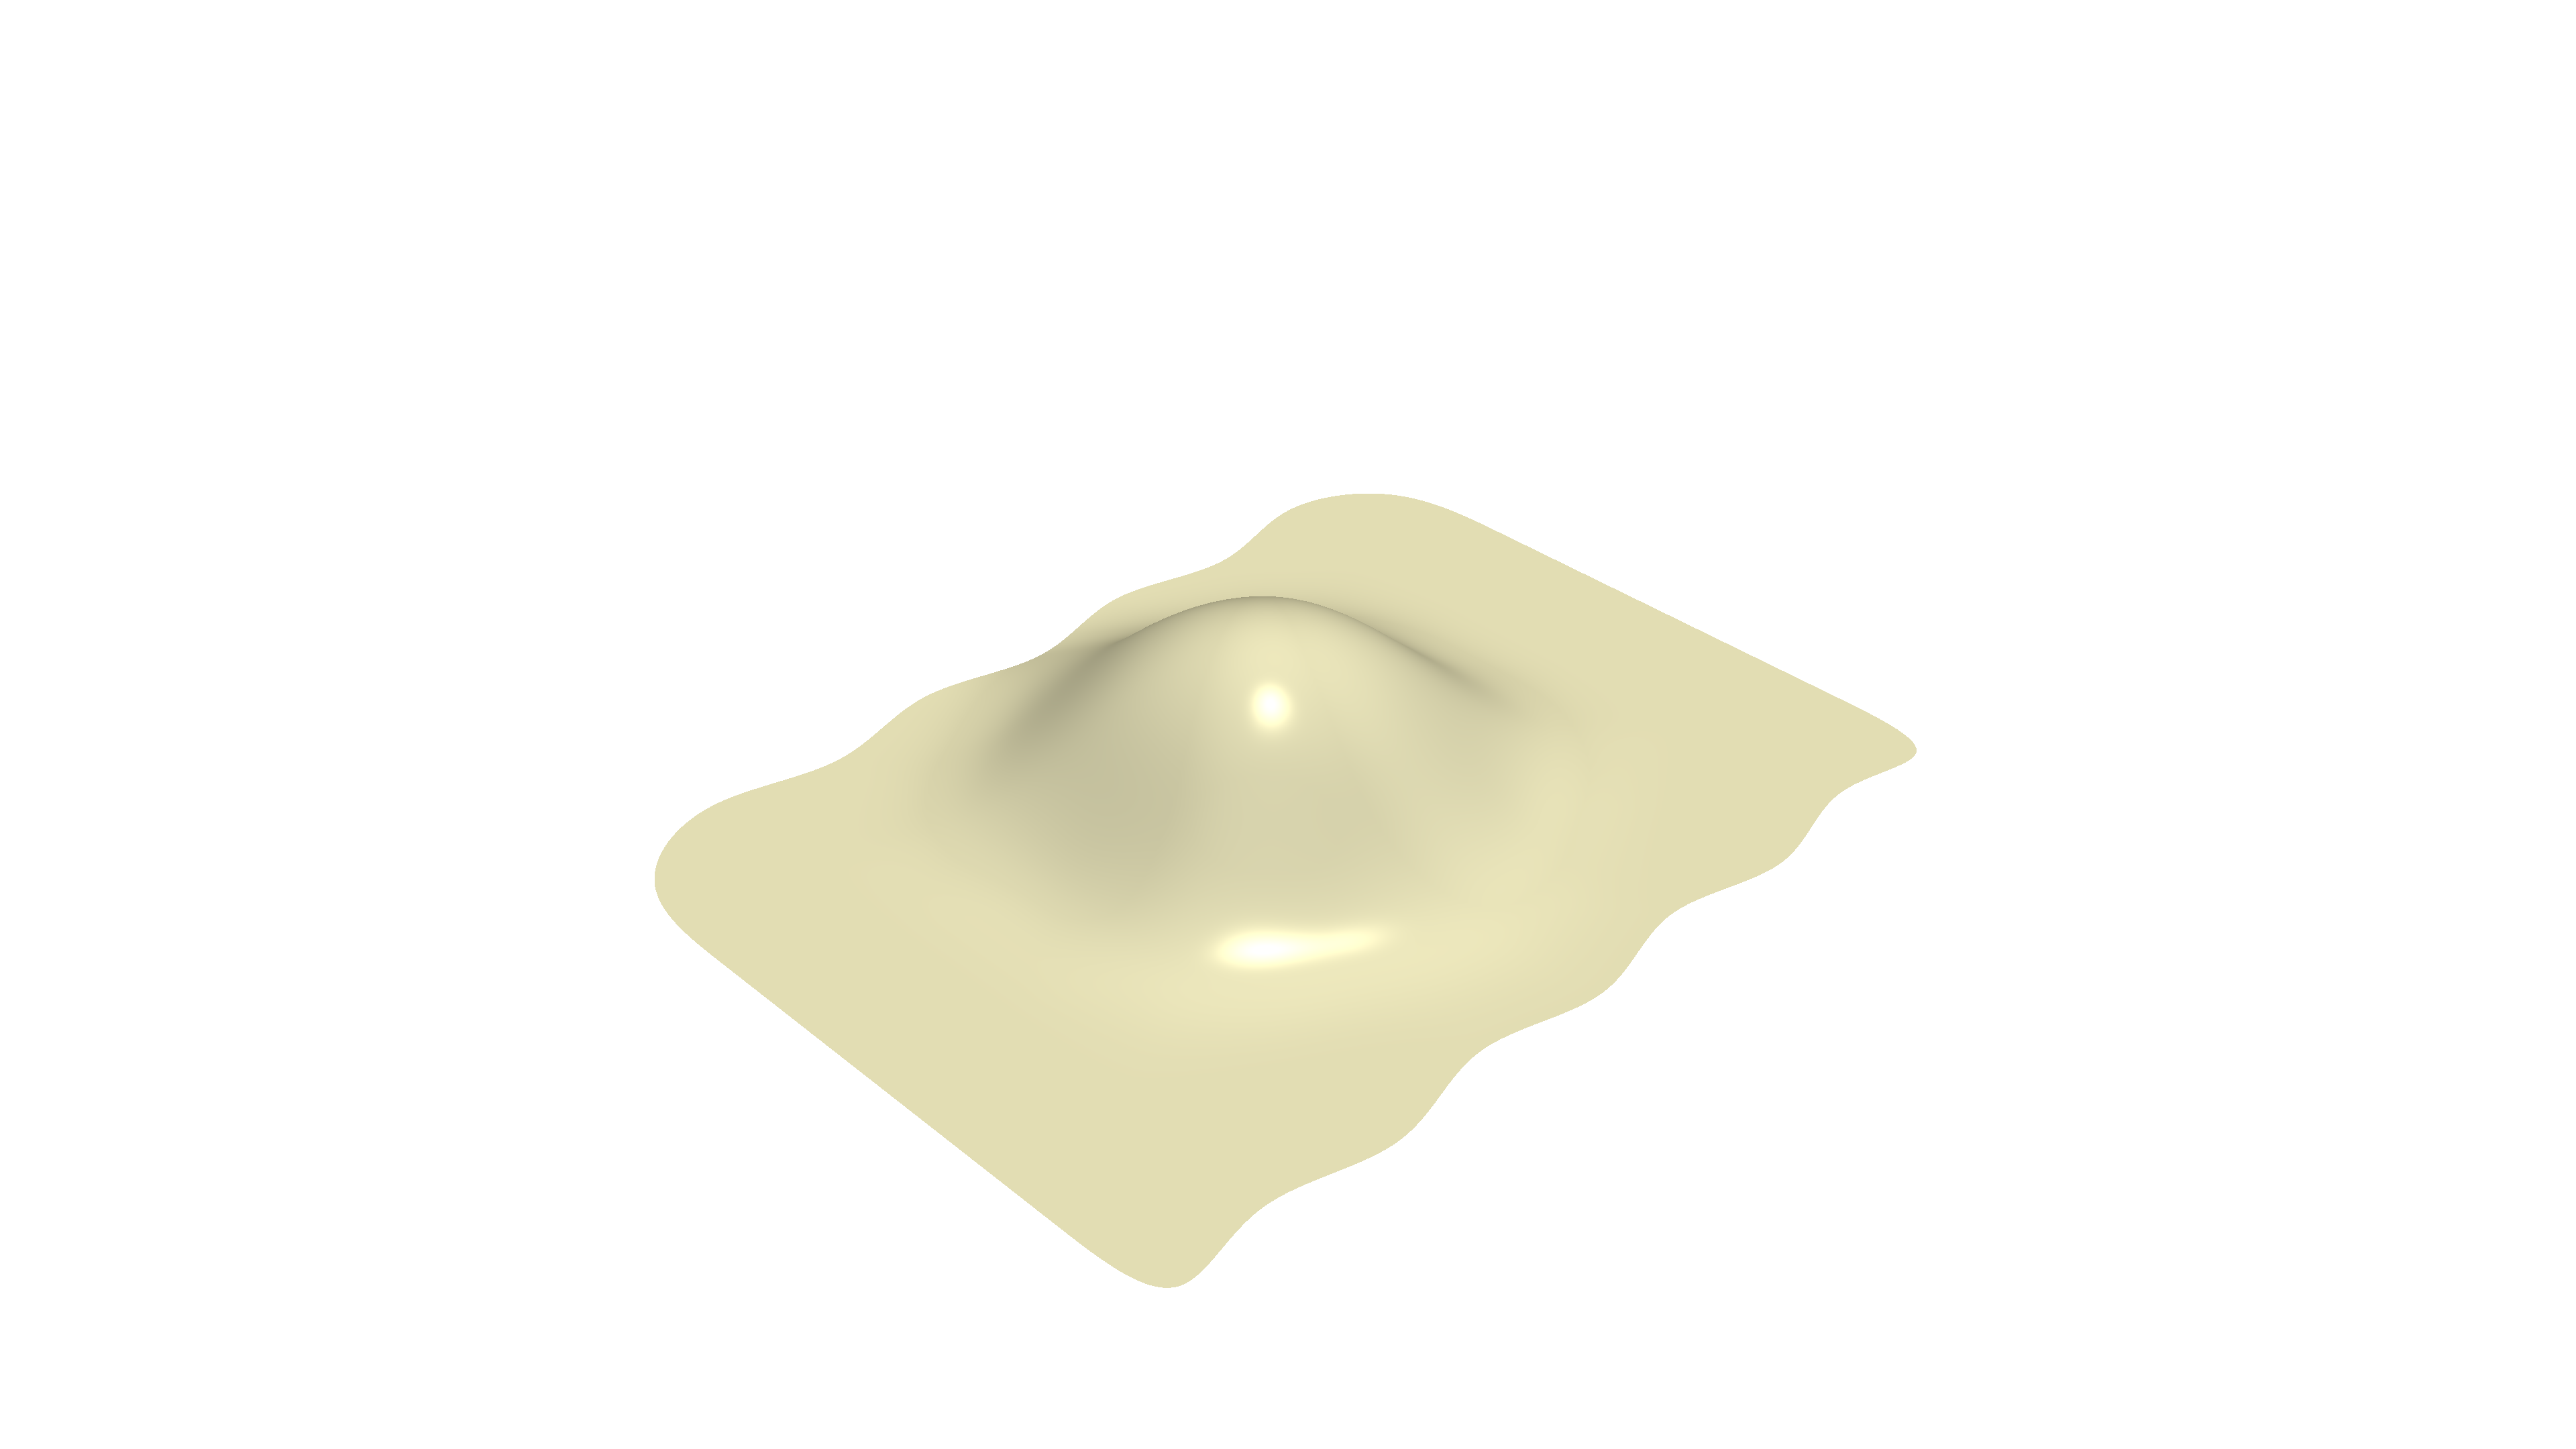

In [35]:
# Create the mesh
tri_mesh = pv.PolyData(mesh.points, faces)

# Apply Loop's subdivision
X_subdiv = tri_mesh.subdivide(5, subfilter='loop')

# Plot the original mesh edge connectivity
# Plot the subdivided mesh
plotter = pv.Plotter()
plotter.background_color = 'white'  # Set the background to white
#plotter.add_mesh(tri_mesh, color='black', style='wireframe', line_width=1)
plotter.add_mesh(X_subdiv, show_edges=False, color='#FFFFDC',
                 smooth_shading=True, specular=0.5)

# Set a high window size for high resolution
plotter.window_size = [3840, 2160]  # Increase the size for higher resolution

# Render the plot and save as a high-resolution PNG
plotter.screenshot('graph_limit_surface_high_resolution_plot_emphasize_surface.png')

plotter.show()